<a href="https://colab.research.google.com/github/cerr/pycerr-notebooks/blob/main/autosegment_CT_HeadAndNeck_OARs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
This notebook demonstrates how to sum dose plans, including registration and fractionation correction as needed.

* We address 3 scenarios:
**i. Multiple dose plans on the same CT**     
&nbsp; Each plan is fractionation-corrected to EQD2, before summing the corrected doses.
**ii. Multiple dose plans on different CTs**
&nbsp; Each plan is first converted to EQD2. Plans *2* through *n* are then registered to the reference (*1st*) plan before summing the doses.
**iii. Combination of *i* and *ii.***
&nbsp; All plans are first converted to EQD2. Plans associated with the same CT are summed and the result is registered to the reference CT as in scenario 2, before the final summation.

* Deformable registration is performed via symmetric image normalization<sup>1</sup> using [ANTSpy](https://github.com/ANTsX/ANTsPy).

-------------

***Requirements***

* pyCERR<sup>3</sup>
* ANTSpy  

***Inputs***
* DICOM format CTs, RTplans.    
* DICOM RTStructs of the structures of interest.  
This example uses masseters and medial_pterygoids auto-segmented using a published model <sup>2</sup>.
* Spreadsheet specifying plan names, prescribed doses (Gy) and fraction numbers.
  
***Outputs***
* NIfTI-format summed dose, associated CT and ROIs.
* Spreadsheet containing user-specifed DVH metrics (here, mean dose) computed from summed dose.

***References***
1. Avants, Brian B., et al. "Symmetric diffeomorphic image registration with cross-correlation: evaluating automated labeling of elderly and neurodegenerative brain." Medical image analysis 12.1 (2008): 26-41.
2. Apte, A. P.et al. "Artificial intelligence apps for medical image analysis using pyCERR and cancer genomics cloud". Medical Physics, 52 (2025): e70059. Meeting Abstract:SU-330-GPD-T-625. https://doi.org/10.1002/mp.70059
3. Iyer, Aditi, et al. "Prospectively-validated deep learning model for segmenting swallowing and chewing structures in CT." Physics in Medicine & Biology 67.2 (2022): 024001.

-----
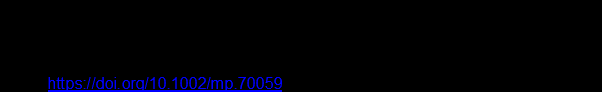
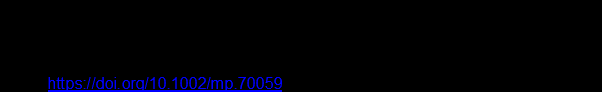
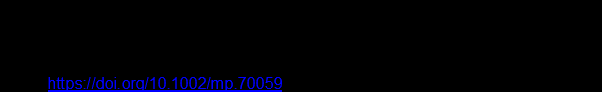
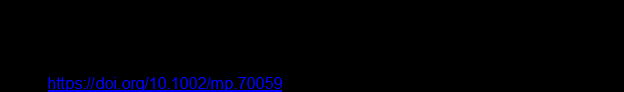

## Import required libraries

In [ ]:
import datetime
import os
import json
import ants
import numpy as np
import pandas as pd

## User settings

In [ ]:
# Variations of structure names to consider
searchStrList = [['Left_masseter', 'Masseter_L', 'Masseter_L1', 'Masseter_L2', 'Masseter_L3'],
               ['Right_masseter', 'Masseter_R', 'Masseter_R1', 'Masseter_R2', 'Masseter_R3'],
               ['Left_medial_pterygoid', 'Pterygoid_L', 'Pterygoid_L1', 'Pterygoid_L2', 'Pterygoid_L3',
                'Pterygoid_Lt'],
               ['Right_medial_pterygoid', 'Pterygoid_R', 'Pterygoid_R1', 'Pterygoid_R2', 'Pterygoid_R3',
                'Pterygoid_Rt']]

In [ ]:
# Structure-to-label mapping
roiDict = {'Left_masseter': 1, 'Right_masseter':2, 'Left_medial_pterygoid':3, 'Right_medial_pterygoid':4}
flipDict = dict((v,k) for k,v in roiDict.items())
roiDictDef = {'Left_masseter_warped': 1, 'Right_masseter_warped': 2,
              'Left_medial_pterygoid_warped': 3, 'Right_medial_pterygoid_warped': 4}

doseInfoS = {'fractionGroupID': 'summedDose', 'doseUnits': 'GRAY'}

In [ ]:
# Parameters for fractionation correction
correctionType = 'fractionSize'
abRatio = 3
stdFrxSize = 2

# Supporting functions

### Data preparation
This function identifies relevant RT objects for each patient in the cohort, filters, and exports them to NIfTI format for ease of analysis and speed. Doses are converted to the specified fraction size using input abRatio. Relevant metadata are written to JSON-format files.

In [ ]:
from cerr import plan_container as pc
from cerr.dataclasses.dose import getFrxSize, fractionSizeCorrect, sum
from cerr.dataclasses.scan import getScanNumFromUID

def exportDataToNii(dataPath, outputPath, frxSizeFile):
    """
    Read and filter DICOM data, export relevant objects to NIfTI.
    1. Import all DICOM data (scans, structures, doses) to planC.
    2. Filter out extraneous objects.
    3. Correct doses to std. frx size
    4. Export relevant scans, associated doses and ROIs to NIfTI.

    Args:
        dataPath (str)    : Path to input DICOM data
        outputPath (str)  : Path to write NIfTI data
        frxSizeFile (str) : Path to Excel spreadsheet with columns 'MRN', 'Plan i', 'Fxi', 'Di[Gy]', i=1,2,3... for each plan
    """

    ptList = os.listdir(dataPath)

    #-----------------------
    # Fractionation info.
    # -----------------------
    dataXLS = pd.read_excel(frxSizeFile, na_filter=True, dtype={'MRN': str,'Plan 1': str,
                                                                'Fx1': np.float32, 'D1 [Gy]': np.float32,
                                                                'Plan 2': str,	'Fx2': np.float32, 'D2 [Gy]': np.float32,
                                                                'Plan 3': str, 'Fx3': np.float32, 'D3 [Gy]': np.float32,
                                                                'Plan 4': str,	'Fx4': np.float32, 'D4 [Gy]': np.float32})
    ptXLS = list(dataXLS['MRN'])

    #-----------------------
    # Loop over patients
    # -----------------------
    for pt in ptList:

            # Import all data to planC
            dcmDir = os.path.join(dataPath, pt)
            planC = pc.loadDcmDir(dcmDir)

            # Get ordered dose list
            doseIndices = np.arange(0, len(planC.dose))
            assocScanUIDs = [planC.dose[doseIndex].assocScanUID for doseIndex in doseIndices]
            assocScanNums = [getScanNumFromUID(assocScanUID, planC) for assocScanUID in assocScanUIDs]
            scanDates = [planC.scan[scnNum].scanInfo[0].seriesDate for scnNum in assocScanNums]
            dateObjList = [datetime.datetime.strptime(date, '%Y%m%d') for date in scanDates]
            sortOrder = np.argsort(np.array(dateObjList))

            # Identify baseline scan
            baseScanIndex = assocScanNums[sortOrder[0]]

            # Identify moving scans with associated doses to be summed
            newScanIndices = np.array(assocScanNums) != baseScanIndex
            movScanNums = np.array(assocScanNums)[newScanIndices].tolist()
            warpIndices = np.where(newScanIndices)[0].tolist()
            scansToExport = list(np.unique(movScanNums))
            scansToExport.insert(0,baseScanIndex)

            # Export scans, along with relevant associated doses & structs
            ptOutDir = os.path.join(outputPath, pt)
            status = os.makedirs(ptOutDir, exist_ok=True)
            doseInfo = {}
            for idx in range(len(scansToExport)):

                # Save scan
                scanNum = scansToExport[idx]
                assocDoseIdxV = doseIndices[np.array(assocScanNums) == scanNum]
                if idx==0:
                    scanFileName = 'base_scan.nii.gz'
                    structFileName = 'base_structs.nii.gz'
                else:
                    scanFileName = 'mov_scan' + str(scanNum) + '.nii.gz'
                    structFileName = 'mov' + str(scanNum) + '_structs' + '.nii.gz'

                planC.scan[scanNum].saveNii(os.path.join(ptOutDir, scanFileName))

                #Save associated structs
                strIdxV = getStrIndices(planC, scanNum, searchStrList)
                niiFilePath = os.path.join(ptOutDir, structFileName)
                pc.saveNiiStructure(niiFilePath, roiDict, planC, strNumV=strIdxV, dim=3)

                # Sum assoc. doses
                matchIdx = ptXLS.index(pt)
                matchInfoS = dataXLS.loc[matchIdx, :]
                matchPlans = [matchInfoS['Plan 1'], matchInfoS['Plan 2'], matchInfoS['Plan 3'], matchInfoS['Plan 4']]
                if len(assocDoseIdxV) > 1:

                    # Convert to 2Gy/fx
                    for d in range(len(assocDoseIdxV)):

                        doseNum = assocDoseIdxV[d]
                        doseName = planC.dose[doseNum].fractionGroupID

                        # Get original fraction size
                        if doseName in matchPlans:
                            dNum = matchPlans.index(doseName)
                        else:
                            dNum = d
                        inputFrxSize = matchInfoS['D' + str(dNum+1) + ' [Gy]']/matchInfoS['Fx' + str(dNum+1)]

                        # Record frx size
                        if idx == 0:
                            doseFileOrig = 'base_dose' + str(doseNum) + '.nii.gz'
                        else:
                            doseFileOrig = 'mov_dose' + str(doseNum) + '.nii.gz'
                        doseInfo[doseFileOrig] = inputFrxSize

                        # Export orig dose
                        niiFilePath = os.path.join(ptOutDir, doseFileOrig)
                        planC.dose[doseNum].saveNii(niiFilePath)

                        # Frx correct dose
                        doseArray = planC.dose[doseNum].doseArray
                        doseArrayCorr = fractionSizeCorrect(doseArray, stdFrxSize, abRatio,
                                                            planC=planC, inputFrxSize=inputFrxSize)
                        planC.dose[doseNum].doseArray = doseArrayCorr

                    # Sum doses associated with the same scan
                    summedDose, refGrid = sum(assocDoseIdxV, planC) #Pre-corrected
                    planC = pc.importDoseArray(summedDose, refGrid[0], refGrid[1], refGrid[2],
                                               planC, scanNum, doseInfo=doseInfoS)
                    outDoseNum = len(planC.dose) - 1
                    if idx == 0:
                        doseFileCorr = 'base_dose_corr' + str(outDoseNum) + '_sum.nii.gz'
                    else:
                        doseFileCorr = 'mov_dose_corr' + str(outDoseNum) + '_sum.nii.gz'

                else:
                    outDoseNum = assocDoseIdxV[0]
                    doseName = planC.dose[outDoseNum].fractionGroupID

                    # Get original fraction size
                    if doseName in matchPlans:
                        dNum = matchPlans.index(doseName)
                    else:
                        dNum = 0
                    inputFrxSize = matchInfoS['D' + str(dNum + 1) + ' [Gy]'] / matchInfoS['Fx' + str(dNum + 1)]

                    # Record original fraction size
                    if idx==0:
                        doseFileOrig = 'base_dose' + str(outDoseNum) + '.nii.gz'
                        doseFileCorr = 'base_dose_corr' + str(outDoseNum) + '.nii.gz'
                    else:
                        doseFileOrig = 'mov_dose' + str(outDoseNum) + '.nii.gz'
                        doseFileCorr = 'mov_dose_corr' + str(outDoseNum) + '.nii.gz'
                    doseInfo[doseFileOrig] = inputFrxSize

                    # Export orig dose
                    niiFilePath = os.path.join(ptOutDir, doseFileOrig)
                    planC.dose[outDoseNum].saveNii(niiFilePath)

                    # Convert to 2Gy/fx
                    doseArray = planC.dose[outDoseNum].doseArray
                    outDoseArray = fractionSizeCorrect(doseArray, stdFrxSize, abRatio, planC=planC,
                                                       inputFrxSize=inputFrxSize)
                    planC.dose[outDoseNum].doseArray = outDoseArray

                # Export corrected, summed dose to NIfTI
                niiFilePath = os.path.join(ptOutDir, doseFileCorr)
                planC.dose[outDoseNum].saveNii(niiFilePath)

            doseInfoFile = os.path.join(ptOutDir,"dose_info.json")
            with open(doseInfoFile, "w") as jsonFile:
                json.dump(str(doseInfo), jsonFile)

    return 0

### Identifying structures of interest

In [ ]:
from cerr.contour.rasterseg import getStrMask

def getStrIndices(planC, scanNum, selStrList):
    """
    Returns indices of ROIs associated with input scanNum.
    """

    # Extract all available structures
    strList = [str.structureName for str in planC.structure]

    # Identify matches
    strIdxV = np.zeros(len(selStrList), dtype=int)
    for m in range(len(selStrList)):
        idx = []
        for n in range(len(selStrList[m])):
            idxV = [i for i, v in enumerate(strList) if v == selStrList[m][n]]
            if len(idxV) == 0:
                continue
            if not isinstance(idxV, list):
                idxV = [idxV]
            assocUIDv = [planC.structure[idx].assocScanUID for idx in idxV]
            currScanUID = planC.scan[scanNum].scanUID
            scanMatchIdx = assocUIDv.index(currScanUID) if currScanUID in assocUIDv else None
            if scanMatchIdx is not None:
                idx = idxV[scanMatchIdx]
                if not isinstance(idx, list):
                    idx = [idx]
            if len(idx) > 0:
                idx = [idx[-1]]  # Use latest
                break
        if len(idx) == 0:
            # Alert on error
            raise ValueError("Error! " + selStrList[m][0] + "missing.")
        else:
            outStrNum = int(idx[0])
            M = getStrMask(outStrNum, planC)
            if np.sum(np.sum(np.sum(M))) == 0:
                err = "Error! " + selStrList[m][0] + " mask is empty."
                raise ValueError(err)
            strIdxV[m] = outStrNum

    return strIdxV

### Gathering relevant NIfTI files for analysis

In [ ]:
def filterFileList(baseDir, keepStr, skipStr):
    """
    Filter NIfTI data and return names of valid scan, dose, struct files.
    """

    validScanFiles = []
    validStructFiles = []
    validDoseFiles = []
    keepList = ['scan', 'structs', 'dose_corr']
    skipList = ['warped']
    allowStr = keepStr + '_dose_corr'
    keepList.insert(0, keepStr)
    skipList.insert(0,skipStr)

    for file in os.listdir(baseDir):
        filePath = os.path.join(baseDir, file)

        if not os.path.isfile(filePath):
            continue

        if not file.endswith('.nii.gz'):
            continue

        if not any(keepStr in file for keepStr in keepList):
            continue

        if any([skipStr in file for skipStr in skipList]):
            continue

        if 'dose' in file and allowStr not in file:
            continue

        if 'scan' in file:
            validScanFiles.append(file)
        elif 'struct' in file:
            validStructFiles.append(file)
        elif  'dose' in file:
            validDoseFiles.append(file)

    return validScanFiles, validStructFiles, validDoseFiles

def loadNii(baseDir, matchStr, skipStr, planC):
    """
    Import NIfTI data to planC
    """
    scanFile, structFile, doseFiles = filterFileList(baseDir, matchStr, skipStr)
    if len(scanFile)>0:
        planC = pc.loadNiiScan(os.path.join(baseDir, scanFile[0]), 'CT SCAN', initplanC=planC)
        scanNum = len(planC.scan) - 1
        planC = pc.loadNiiStructure(os.path.join(baseDir, structFile[0]), scanNum, planC, labels_dict=flipDict)
        for file in doseFiles:
            # Load corrected, summed dose array(s)
            planC = pc.loadNiiDose(os.path.join(baseDir, file), scanNum, planC)
    return planC, scanFile, structFile, doseFiles

### Registering subsequent CT scans to baseline

*registerScansANTS* deforms moving scans, associated doses and ROIs to baseline. Dice similarity coefficient and 95th percentile Hausdorff distance are recorded as to meaure registration quality.

In [ ]:
import ants
from cerr.registration import register
from surface_distance import compute_surface_distances, compute_dice_coefficient, compute_robust_hausdorff

def registerScansANTS(planC, baseScanNum, movScanNum, movDoseFileList, doseInfo, ptDir):

    # Identify fixed and moving files
    movScanUID = planC.scan[movScanNum].scanUID
    baseScanFile = os.path.join(ptDir, 'base_scan.nii.gz')
    movScanFile = os.path.join(ptDir, 'mov_scan' + str(movScanNum) + '.nii.gz')
    movStrName = 'mov' + str(movScanNum) + '_structs' + '.nii.gz'
    movStrFile = os.path.join(ptDir,movStrName)
    movDoseNumV = [d for d in range(len(planC.dose)) if planC.dose[d].assocScanUID == movScanUID]

    # Read fixed and moving images
    imgAntsBase = ants.image_read(baseScanFile)
    imgAntsMov = ants.image_read(movScanFile)
    movScanName = os.path.basename(movScanFile)
    warpedScanFileName = os.path.join(ptDir, 'warped_' + movScanName)

    # Register images
    txLoc = os.path.join(ptDir,'ants_reg')
    regFile = os.path.join(ptDir, 'ants_regComposite.h5')
    loadFromFile = 1
    if not os.path.isfile(regFile):
        loadFromFile = 0
        result = ants.registration(imgAntsBase, imgAntsMov, type_of_transform = 'SyN',
                               write_composite_transform = True, outprefix = txLoc)
        warpedScanImage = ants.apply_transforms(fixed=imgAntsBase, moving=imgAntsMov,
                                            transformlist=result['fwdtransforms'])
        warpedScanImage.image_write(warpedScanFileName)
    else:
        if not os.path.isfile(warpedScanFileName):
            warpedScanImage = ants.apply_transforms(fixed=imgAntsBase, moving=imgAntsMov,
                                                transformlist=regFile)
            warpedScanImage.image_write(warpedScanFileName)
    planC = pc.loadNiiScan(warpedScanFileName, 'CT SCAN', '', planC)
    warpedScanNum = len(planC.scan) - 1

    # Warp associated ROIs
    warpedStrFileName = os.path.join(ptDir, 'warped_movscan' + str(movScanNum) + '_structs.nii.gz')
    imgAntsMovStr = ants.image_read(movStrFile)
    if not loadFromFile:
        warpedStrImage = ants.apply_transforms(fixed=imgAntsBase, moving=imgAntsMovStr,
                                           transformlist=result['fwdtransforms'],
                                           defaultvalue=0, singleprecision=True)
        warpedStrImage.image_write(warpedStrFileName)
    else:
        if not os.path.isfile(warpedStrFileName):
            warpedStrImage = ants.apply_transforms(fixed=imgAntsBase, moving=imgAntsMovStr,
                                           transformlist=regFile,
                                           defaultvalue=0, singleprecision=True)
            warpedStrImage.image_write(warpedStrFileName)
    planC = pc.loadNiiStructure(warpedStrFileName, warpedScanNum, planC, flipDict)
    defStrNums = np.arange(len(planC.structure) - 4, len(planC.structure))
    baseStrNums = getStrIndices(planC, baseScanNum, searchStrList)

    # Warp doses
    warpedDoseNumV = []
    for fileNum in range(len(movDoseFileList)):
        doseFileName = os.path.basename(movDoseFileList[fileNum])
        doseNum = movDoseNumV[fileNum]
        warpedDoseFileName = os.path.join(ptDir, 'warped_' + doseFileName)

        if not os.path.isfile(warpedDoseFileName):
            imgAntsMovDose = ants.image_read(os.path.join(ptDir, movDoseFileList[fileNum]))
            if loadFromFile:
                warpedDoseImage = ants.apply_transforms(fixed=imgAntsBase, moving=imgAntsMovDose,
                                                transformlist=regFile)

            else:
                warpedDoseImage = ants.apply_transforms(fixed=imgAntsBase, moving=imgAntsMovDose,
                                                transformlist=result['fwdtransforms'])
            warpedDoseImage.image_write(warpedDoseFileName)

        warpedDoseName = 'warped_' + doseFileName.split('.')[0]
        planC = pc.loadNiiDose(warpedDoseFileName, movScanNum, planC, fractionGroupID=warpedDoseName)
        warpedDoseNum = len(planC.dose)-1
        warpedDoseNumV.append(warpedDoseNum)


    # Record registration performance metrics
    dice = []
    hd95 = []
    spacing_mm = planC.scan[baseScanNum].getScanSpacing() * 10
    for idx in range(len(defStrNums)):
        M1 = getStrMask(baseStrNums[idx], planC)
        M2 = getStrMask(defStrNums[idx], planC)
        surf_dists = compute_surface_distances(M1, M2, spacing_mm)
        dice.append(compute_dice_coefficient(M1, M2))
        hd95.append(compute_robust_hausdorff(surf_dists, 95))

    return planC, warpedScanNum, warpedDoseNumV, dice, hd95

## Main function
Exporting summed doses and calculating DVH metrics.

In [ ]:
from cerr import dvh

def exportSumDose(basePtPath, regQualFile, logPath):

    ptList = os.listdir(basePtPath)

    roiList = list(roiDict.keys())
    outDoseFileName = 'summed_corr_dose.nii.gz'
    logFileName = 'sum_dose_err.txt'

    # Loop over pts
    dict_list = []
    print('Summing doses...')
    for pt in ptList:

        try:

            # Load NII data and JSON metadata
            ptDir = os.path.join(basePtPath, pt)
            print('Processing pt {}...'.format(pt))
            planC, __, __, baseDoseFiles = loadNii(ptDir, 'base', 'mov', '')
            planC, __, __, movDoseFiles = loadNii(ptDir, 'mov', 'base', planC)
            numScan = len(planC.scan)

            doseInfoFile = os.path.join(ptDir, "dose_info.json")
            with open(doseInfoFile, 'r') as jsonFile:
                doseInfo = eval(json.load(jsonFile))

            # Identify (summed) dose associated with baseline scan
            baseScanNum = 0
            baseScanUID = planC.scan[baseScanNum].scanUID
            doseNumV = [d for d in range(len(planC.dose)) if planC.dose[d].assocScanUID == baseScanUID]
            frxSizeV = [doseInfo['base_dose'+str(num)+'.nii.gz'] for num in doseNumV]


            # Identify (summed) dose(s) associated with moving scan(s)
            if numScan > 1:
                movScanNumV = np.arange(1, numScan)
                for movScanNum in movScanNumV:
                    #Register using ANTS
                    print('Registering moving scan {}...'.format(str(movScanNum)))
                    planC, warpedScanNum, warpedDoseNumV, dice, hd95 = registerScansANTS(planC,
                                                                                         baseScanNum,
                                                                                         movScanNum,
                                                                                         movDoseFiles,
                                                                                         doseInfo,
                                                                                         ptDir)
                    doseNumV = doseNumV + warpedDoseNumV

                    # Record registration performance
                    for strIdx in range(len(roiList)):
                       dict_list.append({'Pt': pt, 'scan': 'scan ' + str(movScanNum),
                                         'structure': roiList[strIdx], 'DSC': dice[strIdx], 'HD95': hd95[strIdx]})


            # Sum doses
            print('Summing doses across scans...')
            summedDose, refGrid = sum(doseNumV, planC) #Pre-corrected
            planC = pc.importDoseArray(summedDose, refGrid[0], refGrid[1], refGrid[2], planC,
                                       baseScanNum, doseInfo=doseInfoS)
            sumDoseNum = len(planC.dose) - 1

            # Save summed dose to NII
            niiFilePath = os.path.join(ptDir, outDoseFileName)
            sumDose = planC.dose[sumDoseNum]
            sumDose.saveNii(niiFilePath)

        except Exception as e:
            # Record any errors
            logFilePath = os.path.join(logPath, logFileName)
            f = open(logFilePath, "a")
            f.write(pt + + "\t" + str(e) + "\n")
            f.close()

    #Record registration performance
    reg_metrics = pd.DataFrame(dict_list)
    reg_metrics.to_excel(regQualFile)
    print('Complete.')

    return 0

def exportMeanDose(basePtPath, outFile, logPath):

    ptList = os.listdir(basePtPath)
    roiList = list(roiDict.keys())
    logFileName = 'mean_dose_calc_err.txt'

    baseScanNum = 0
    binWidth = 0.05
    dict_list = []

    print('Extracting mean doses...')
    for pt in ptList:

        try:
            planC = pc.loadNiiScan(os.path.join(basePtPath, pt, 'base_scan.nii.gz'), 'CT SCAN')
            planC = pc.loadNiiStructure(os.path.join(basePtPath, pt, 'base_structs.nii.gz'),
                                         baseScanNum, planC, labels_dict=flipDict)
            planC = pc.loadNiiDose(os.path.join(basePtPath, pt, 'summed_corr_dose.nii.gz'), baseScanNum, planC)

            strIdxV = getStrIndices(planC, baseScanNum, searchStrList)
            doseNum = len(planC.dose) - 1

            for sNum in range(len(strIdxV)):
                doseV, volsV, __ = dvh.getDVH(strIdxV[sNum], doseNum, planC)
                doseBinsV, volsHistV = dvh.doseHist(doseV, volsV, binWidth)
                md = dvh.meanDose(doseBinsV, volsHistV)
                dict_list.append({'Pt': pt, 'structure': roiList[sNum], 'meanDose': md})

        except Exception as e:
            print('Logging err..')
            logFilePath = os.path.join(logPath, logFileName)
            f = open(logFilePath, "a")
            f.write(pt + str(e) + "\n")
            f.close()

    print('Writing to file..')
    dose_metrics = pd.DataFrame(dict_list)
    dose_metrics.to_excel(outFile)
    print('Complete.')

    return 0

# Run analysis

In [ ]:
%%capture

# Define I/O paths
dataPath = r'/path/to/DICOM_data'
frxSizeFile = r'Path/to/spreadsheet/'

basePtPath = r'/path/to/write/NIfTI_data'
regQualFile = r'/path/to/output_registration_performance_metrics.xlsx'
meanDoseFile = r'/path/to/output_mean_doses.xlsx'
logPath = r'/path/to/log/errors'

# Filter and export data to NIfTI
exportDataToNii(dataPath, basePtPath, frxSizeFile)

# Compute sum dose
exportSumDose(basePtPath, regPerfPath)

# Calc. mean dose
exportMeanDose(basePtPath, maxDoseFile)